# 💳 Credit Card Fraud & Transaction Risk Analytics
**Portfolio project – Data Analyst / Business Analyst**

**How to use this notebook:** Run the cells from top to bottom (Runtime → Run all, or `Shift+Enter` cell by cell).
You upload `creditcard.csv` **once** (Section 2). At the end (Section 9) one ZIP file with every CSV for **Power BI** is downloaded.

---
## 0. Business understanding (read before coding)

**Business context.** A card issuer loses money on fraudulent transactions and also loses customer trust when genuine
transactions are blocked. The fraud/risk team needs simple, trusted numbers to monitor fraud every day.

**Business challenge.** Fraud is *very rare* (well under 1% of transactions), so it is easy to miss in normal reporting.
The team needs to know **how often** fraud happens, **how much money** is involved, and **where** the risk is concentrated.

**Measurable objectives**
1. Measure fraud frequency (fraud count and fraud rate %) and fraud financial impact (fraud value and fraud value rate %).
2. Compare amount behaviour of fraud vs legitimate transactions (average, median, maximum, distribution).
3. Find which **amount bands** and **elapsed-time periods** carry the highest fraud rate and the highest fraud value.
4. Identify high-value fraud cases and the anonymised features statistically linked to fraud.
5. Define the KPIs for a fraud-risk monitoring dashboard and convert findings into **stakeholder recommendations**.

**Stakeholders:** Fraud/Risk Operations Manager (alert queues), Head of Risk (loss exposure), Product / Card Manager (customer friction), Senior Management (KPIs).

**Important dataset limitations (say this in your interview)**
- `V1–V28` are **anonymised PCA-transformed variables**. They have **no known business meaning**, so this project finds *statistical patterns*, not business attributes.
- `Time` is **elapsed seconds since the first transaction** (the data covers ~48 hours). It is **not clock time**, so we cannot say "fraud happens at night".
- `Amount` has no currency stated in the dataset, so we just call them *amount units*.
- There is no merchant, country, customer or channel information.

## SECTION 1 — Import libraries
**What we are doing:** loading only the 4 libraries we really need (plus 2 small built-in Python helpers for saving files).

| Library | Why |
|---|---|
| `pandas` | tables (DataFrames), grouping, calculations |
| `numpy` | numbers, `log`, bins |
| `matplotlib` | base charts |
| `seaborn` | nicer statistical charts |
| `os`, `zipfile` | built into Python – create a folder and zip the output files |

🎤 **Interview tip:** "I used pandas for analysis and matplotlib/seaborn for visuals. I kept the toolset small so I can explain every line."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, zipfile
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 40)                     # show all columns in tables
pd.set_option('display.float_format', '{:,.4f}'.format)      # 4 decimals, thousands separator
sns.set_style('whitegrid')                                   # clean chart style
COLORS = {'Legitimate': '#4C72B0', 'Fraud': '#C44E52'}       # same 2 colours in every chart
print('Libraries loaded ✅')

Libraries loaded ✅


## SECTION 2 — Load the dataset
**What we are doing:** uploading `creditcard.csv` from your computer into Colab and reading it into a DataFrame called `df`.
A DataFrame is simply a table (rows = transactions, columns = fields).

**Important lines**
- `files.upload()` opens a file picker. Choose `creditcard.csv` (≈144 MB, upload takes a minute or two).
- `pd.read_csv(file_name)` reads the CSV into a table.
- We upload only once. Everything later uses `df` which is already in memory.

🎤 **Interview tip:** "The dataset has 284,807 transactions and 31 columns: Time, V1–V28, Amount and Class."

In [2]:
from google.colab import files
uploaded = files.upload()                      # choose creditcard.csv
file_name = list(uploaded.keys())[0]           # name of the uploaded file
df = pd.read_csv(file_name)                    # read CSV into a DataFrame
print('\nFile loaded:', file_name)

Saving creditcard.csv to creditcard.csv

File loaded: creditcard.csv


In [3]:
print('Shape (rows, columns):', df.shape)
print('\nColumn names:\n', df.columns.tolist())

Shape (rows, columns): (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
display(df.head())          # first 5 rows

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [5]:
print(df.dtypes.value_counts())     # how many columns of each data type
df.info()                           # rows, columns, non-null counts, memory

float64    30
int64       1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64

In [6]:
display(df.describe().T)            # descriptive statistics for each column

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


**What to notice:** all 31 columns are numeric. `Amount` has a mean far above its median (skewed), and its max is very large compared with the 75th percentile –
so a few very large transactions exist. `Class` is mostly 0.

## SECTION 3 — Data quality check
**What we are doing:** checking whether the data can be trusted *before* analysing it. We only **check** here – we do not delete anything yet.

| Check | Why it matters |
|---|---|
| Missing values | would break averages/totals |
| Exact duplicate rows | would double-count transactions |
| Data types | numbers must be numeric |
| Invalid values | `Class` must be 0/1, `Amount` and `Time` should not be negative |
| Zero amounts | may be verification-type records, need a decision |
| Class distribution | shows how imbalanced the target is |

🎤 **Interview tip:** "Before any analysis I checked missing values, duplicates, data types and invalid values."

In [7]:
missing_total       = df.isnull().sum().sum()                       # total empty cells
duplicate_rows      = df.duplicated().sum()                         # rows that repeat an earlier row EXACTLY (all 31 columns)
duplicate_fraud     = df[df.duplicated()]['Class'].sum()            # how many of those duplicates are fraud
non_numeric_cols    = df.select_dtypes(exclude='number').columns.tolist()
invalid_class       = (~df['Class'].isin([0, 1])).sum()             # Class values other than 0/1
negative_amount     = (df['Amount'] < 0).sum()
zero_amount         = (df['Amount'] == 0).sum()
zero_amount_fraud   = ((df['Amount'] == 0) & (df['Class'] == 1)).sum()
negative_time       = (df['Time'] < 0).sum()

dq = pd.DataFrame({
    'Check': ['Total rows', 'Total columns', 'Missing values (all cells)', 'Exact duplicate rows',
              '  of which fraud duplicates', 'Non-numeric columns', 'Invalid Class values (not 0/1)',
              'Negative Amount', 'Zero Amount', '  of which fraud', 'Negative Time'],
    'Result': [len(df), df.shape[1], missing_total, duplicate_rows, duplicate_fraud,
               len(non_numeric_cols), invalid_class, negative_amount, zero_amount, zero_amount_fraud, negative_time]
})
display(dq)

,Check,Result
0,Total rows,284807
1,Total columns,31
2,Missing values (all cells),0
3,Exact duplicate rows,1081
4,of which fraud duplicates,19
5,Non-numeric columns,0
6,Invalid Class values (not 0/1),0
7,Negative Amount,0
8,Zero Amount,1825
9,of which fraud,27


In [8]:
# Class distribution (0 = legitimate, 1 = fraud)
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Count': class_counts, 'Percent %': class_pct}))

,Count,Percent %
Class,,
0,284315,99.8273
1,492,0.1727


### Data-quality decisions (and why)
| Finding | Decision | Reason |
|---|---|---|
| No missing values | Nothing to fix | – |
| All columns numeric | Nothing to fix | – |
| No negative Amount / Time, `Class` only 0 or 1 | Nothing to fix | – |
| **Exact duplicate rows exist** | **Remove them** (Section 4) | A row identical in all 31 columns, including 28 high-precision PCA values and `Time`, is almost certainly a repeated record. Keeping it would double-count transactions and fraud value. |
| **Zero-amount transactions exist** | **Keep them** | `0` is a valid value (could be card-verification style records – we cannot confirm). They do not distort totals. We only note them. |
| Class is extremely imbalanced | Do **not** resample | We are doing analytics, not ML. We just report **rates** instead of relying on counts or accuracy. |

🎤 **Interview tip:** "My biggest data-quality issue was duplicate rows. I removed exact duplicates only and kept zero-amount rows because they are valid values."

## SECTION 4 — Data cleaning & feature creation
**What we are doing:** one necessary cleaning step (remove exact duplicates) and creating readable analysis columns.

**New columns**
| Column | Meaning |
|---|---|
| `Transaction_Type` | "Legitimate" / "Fraud" (readable version of `Class`) |
| `Time_Hours` | `Time / 3600` – elapsed hours since the first transaction |
| `Time_Period` | 8 elapsed-time bins of 6 hours each: 0–6, 6–12 … 42–48 hrs. ⚠️ **Not clock time.** The data covers ~48 hours so we need 8 bins (not 4) to include every transaction. |
| `Elapsed_Hour` | whole elapsed hour 0–47 (for a more detailed time chart) |
| `Amount_Band` | 0 to 10, 10 to 50, 50 to 100, 100 to 500, 500+ (upper edge included, e.g. exactly 10 → "0 to 10"). Bands were chosen after inspecting the data: the median amount is ~22, 75% of transactions are under ~77, and very high amounts are rare. |
| `*_Order` columns | simple numbers 1,2,3… so Power BI can sort bands/periods in the right order |
| `Fraud_Amount` | = Amount if fraud, else 0. Makes "fraud value" a simple sum. |
| `Log_Amount` | `log(1 + Amount)` – **only for charts**, because Amount is highly skewed |

Labels are written like `0 to 10` (not `0-10`) so Excel/Power BI never mistakes them for dates.

**Switch:** `REMOVE_DUPLICATES = True`. Change to `False` if you prefer to keep all 284,807 rows (numbers will differ slightly).

In [9]:
REMOVE_DUPLICATES = True

df_clean = df.copy()                                   # work on a copy, keep the original untouched
rows_before = len(df_clean)

if REMOVE_DUPLICATES:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)   # remove exact duplicate rows only

rows_removed = rows_before - len(df_clean)
print(f'Rows before: {rows_before:,} | Rows removed: {rows_removed:,} | Rows after: {len(df_clean):,}')
print('Fraud cases before:', int(df['Class'].sum()), '| after:', int(df_clean['Class'].sum()))

Rows before: 284,807 | Rows removed: 1,081 | Rows after: 283,726
Fraud cases before: 492 | after: 473


In [10]:
# 1) readable transaction type
df_clean['Transaction_Type'] = df_clean['Class'].map({0: 'Legitimate', 1: 'Fraud'})

# 2) elapsed time in hours (NOT clock time)
df_clean['Time_Hours'] = df_clean['Time'] / 3600

# 3) 6-hour elapsed-time periods (right=False means 0 <= hours < 6, 6 <= hours < 12 ...)
period_edges  = [0, 6, 12, 18, 24, 30, 36, 42, 48]
period_labels = ['0 to 6 hrs', '6 to 12 hrs', '12 to 18 hrs', '18 to 24 hrs',
                 '24 to 30 hrs', '30 to 36 hrs', '36 to 42 hrs', '42 to 48 hrs']
df_clean['Time_Period'] = pd.cut(df_clean['Time_Hours'], bins=period_edges, labels=period_labels, right=False)
df_clean['Time_Period_Order'] = df_clean['Time_Period'].cat.codes + 1        # 1..8 for sorting
df_clean['Elapsed_Hour'] = np.floor(df_clean['Time_Hours']).astype(int)       # 0..47

# 4) amount bands (right=True means the upper edge is included: 10 goes to '0 to 10')
amount_edges  = [-0.01, 10, 50, 100, 500, np.inf]
amount_labels = ['0 to 10', '10 to 50', '50 to 100', '100 to 500', '500+']
df_clean['Amount_Band'] = pd.cut(df_clean['Amount'], bins=amount_edges, labels=amount_labels)
df_clean['Amount_Band_Order'] = df_clean['Amount_Band'].cat.codes + 1        # 1..5 for sorting

# 5) helper columns
df_clean['Fraud_Amount'] = np.where(df_clean['Class'] == 1, df_clean['Amount'], 0)   # amount only for fraud rows
df_clean['Log_Amount']   = np.log1p(df_clean['Amount'])                              # for charts only

# 6) safety check: every row must have a period and a band
print('Rows without Time_Period:', df_clean['Time_Period'].isnull().sum())
print('Rows without Amount_Band:', df_clean['Amount_Band'].isnull().sum())
display(df_clean[['Time', 'Time_Hours', 'Time_Period', 'Amount', 'Amount_Band', 'Class', 'Transaction_Type']].head())

Rows without Time_Period: 0
Rows without Amount_Band: 0


,Time,Time_Hours,Time_Period,Amount,Amount_Band,Class,Transaction_Type
0,0.0000,0.0000,0 to 6 hrs,149.6200,100 to 500,0,Legitimate
1,0.0000,0.0000,0 to 6 hrs,2.6900,0 to 10,0,Legitimate
2,1.0000,0.0003,0 to 6 hrs,378.6600,100 to 500,0,Legitimate
3,1.0000,0.0003,0 to 6 hrs,123.5000,100 to 500,0,Legitimate
4,2.0000,0.0006,0 to 6 hrs,69.9900,50 to 100,0,Legitimate


**Important lines explained**
- `df.copy()` – so the raw data is never changed.
- `drop_duplicates()` – removes rows identical to an earlier row.
- `.map({0:..., 1:...})` – replaces 0/1 by words.
- `pd.cut(...)` – puts numbers into bins (groups) with labels.
- `np.where(condition, a, b)` – "if fraud use Amount, else 0".

🎤 **Interview tip:** "Time is elapsed seconds, so I called the bins *elapsed-time periods* and never claimed they are night or day."

## SECTION 5 — Exploratory Data Analysis (EDA)
Business-focused analysis. Keep in mind the 4 numbers we will keep separating:
- **Transaction count** – how many transactions
- **Fraud rate** – fraud transactions ÷ all transactions (frequency)
- **Fraud amount / value** – total money in fraud transactions (financial impact)
- **Fraud value rate** – fraud value ÷ total transaction value

### A. Fraud distribution
**What we are doing:** counting legitimate vs fraud transactions and the fraud percentage.

**Class imbalance** means one class is far bigger than the other. Here fraud is a tiny fraction, so a model/report that says "everything is legitimate" would look ~99.8% "accurate" but catch **zero** fraud. That is why we use **rates and values**, not accuracy.

Total transactions      : 283,726
Legitimate transactions : 283,253
Fraud transactions      : 473
Fraud rate              : 0.1667 %   (about 1 in 600 transactions)


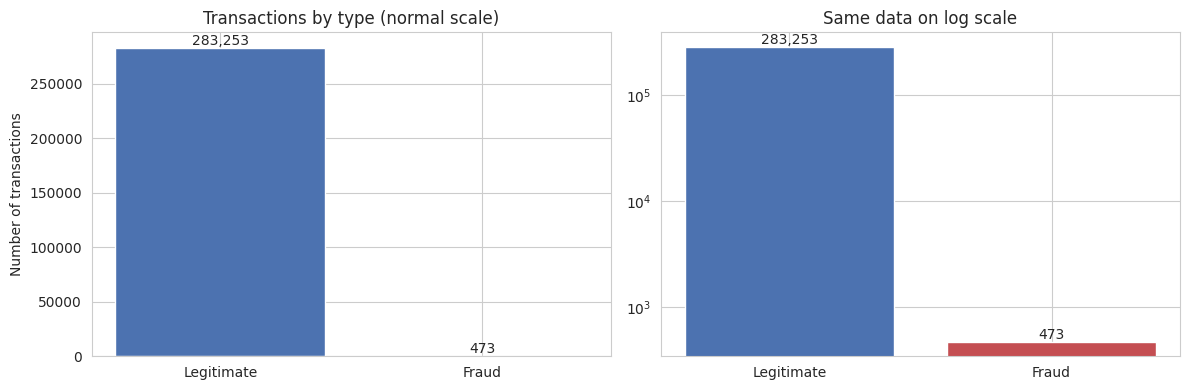

In [11]:
total_txn = len(df_clean)
fraud_txn = int(df_clean['Class'].sum())
legit_txn = total_txn - fraud_txn
fraud_rate_pct = fraud_txn / total_txn * 100

print(f'Total transactions      : {total_txn:,}')
print(f'Legitimate transactions : {legit_txn:,}')
print(f'Fraud transactions      : {fraud_txn:,}')
print(f'Fraud rate              : {fraud_rate_pct:.4f} %   (about 1 in {round(100/fraud_rate_pct):,} transactions)')

counts = df_clean['Transaction_Type'].value_counts().reindex(['Legitimate', 'Fraud'])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# left: normal scale (fraud bar is almost invisible = imbalance)
ax[0].bar(counts.index, counts.values, color=[COLORS[i] for i in counts.index])
ax[0].set_title('Transactions by type (normal scale)')
ax[0].set_ylabel('Number of transactions')
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# right: log scale so both bars are visible
ax[1].bar(counts.index, counts.values, color=[COLORS[i] for i in counts.index])
ax[1].set_yscale('log')
ax[1].set_title('Same data on log scale')
for i, v in enumerate(counts.values):
    ax[1].text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Reading the chart:** on the normal scale the fraud bar is barely visible – that *is* the class imbalance. The log-scale version only helps us see it.

🎤 **Interview tip:** "Fraud is a very small share of transactions, so accuracy is misleading. I handled imbalance by using rates (fraud rate, fraud value rate) and not resampling, because this is an analytics project."

### B. Transaction amount analysis (legitimate vs fraud)
**What we are doing:** comparing count, average, median, maximum and total amount for each type.
Amount is **highly skewed** (many small transactions, few very large). So we show the **median** next to the average and use a **log scale** for charts (`Log_Amount = log(1+Amount)`).

In [12]:
amount_stats = df_clean.groupby('Transaction_Type')['Amount'].agg(
    Transactions='count', Average='mean', Median='median', Maximum='max', Total='sum'
).reindex(['Legitimate', 'Fraud'])
display(amount_stats)

,Transactions,Average,Median,Maximum,Total
Transaction_Type,,,,,
Legitimate,283253,88.4136,22.0000,"25,691.1600","25,043,410.2900"
Fraud,473,123.8719,9.8200,"2,125.8700","58,591.3900"


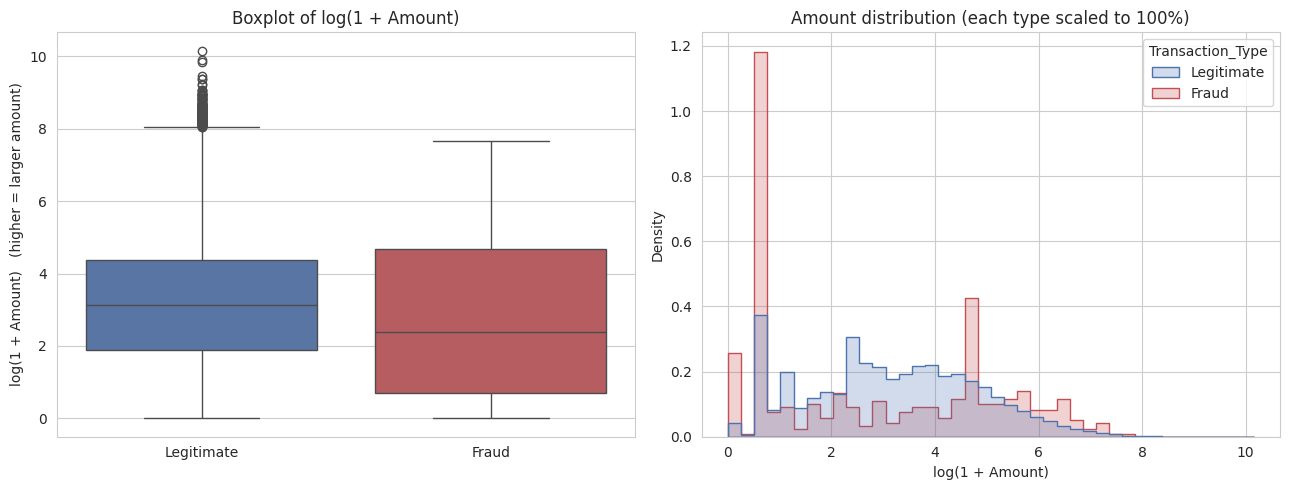

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot on log scale
sns.boxplot(data=df_clean, x='Transaction_Type', y='Log_Amount', order=['Legitimate', 'Fraud'],
            hue='Transaction_Type', palette=COLORS, legend=False, ax=ax[0])
ax[0].set_title('Boxplot of log(1 + Amount)')
ax[0].set_ylabel('log(1 + Amount)   (higher = larger amount)')
ax[0].set_xlabel('')

# Histogram: stat='density' + common_norm=False so each type sums to 100% (fair comparison despite different counts)
sns.histplot(data=df_clean, x='Log_Amount', hue='Transaction_Type', hue_order=['Legitimate', 'Fraud'],
             stat='density', common_norm=False, bins=40, element='step', palette=COLORS, ax=ax[1])
ax[1].set_title('Amount distribution (each type scaled to 100%)')
ax[1].set_xlabel('log(1 + Amount)')
plt.tight_layout()
plt.show()

In [14]:
# Percentiles in real amount units (easy to explain)
percentiles = df_clean.groupby('Transaction_Type')['Amount'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).unstack().reindex(['Legitimate', 'Fraud'])
percentiles.columns = ['P25', 'Median', 'P75', 'P90', 'P95', 'P99']
display(percentiles)

,P25,Median,P75,P90,P95,P99
Transaction_Type,,,,,,
Legitimate,5.6700,22.0000,77.4600,203.0000,365.0000,"1,018.0576"
Fraud,1.0000,9.8200,105.8900,348.6520,655.8200,"1,364.1368"


**How to read:** compare **average vs median** for fraud. If the average is much higher than the median, a few large frauds pull the average up while most frauds are small.
The boxplot shows where the middle 50% of amounts sit; dots outside are unusually large/small values.

🎤 **Interview tip:** "Because amounts are skewed, I compared median as well as average and used a log scale; otherwise a few large transactions would hide everything else."

### C. Fraud by transaction amount band
**What we are doing:** for each amount band: number of transactions, fraud transactions and **fraud rate = fraud ÷ transactions in that band**.

In [15]:
band_summary = df_clean.groupby('Amount_Band', observed=False).agg(
    Total_Transactions=('Class', 'size'),
    Fraud_Transactions=('Class', 'sum'),
    Total_Value=('Amount', 'sum'),
    Fraud_Value=('Fraud_Amount', 'sum')
).reset_index()

band_summary['Fraud_Rate'] = band_summary['Fraud_Transactions'] / band_summary['Total_Transactions']   # decimal, e.g. 0.0024
band_summary['Fraud_Count_Share'] = band_summary['Fraud_Transactions'] / band_summary['Fraud_Transactions'].sum()
band_summary['Fraud_Value_Share'] = band_summary['Fraud_Value'] / band_summary['Fraud_Value'].sum()
band_summary['Sort_Order'] = range(1, len(band_summary) + 1)

show = band_summary[['Amount_Band', 'Total_Transactions', 'Fraud_Transactions', 'Fraud_Value']].copy()
show['Fraud_Rate_%'] = band_summary['Fraud_Rate'] * 100
display(show)

,Amount_Band,Total_Transactions,Fraud_Transactions,Fraud_Value,Fraud_Rate_%
0,0 to 10,99821,238,449.3100,0.2384
1,10 to 50,90327,55,"1,539.8200",0.0609
2,50 to 100,37179,55,"4,867.3300",0.1479
3,100 to 500,47290,91,"21,052.2800",0.1924
4,500+,9109,34,"30,682.6500",0.3733


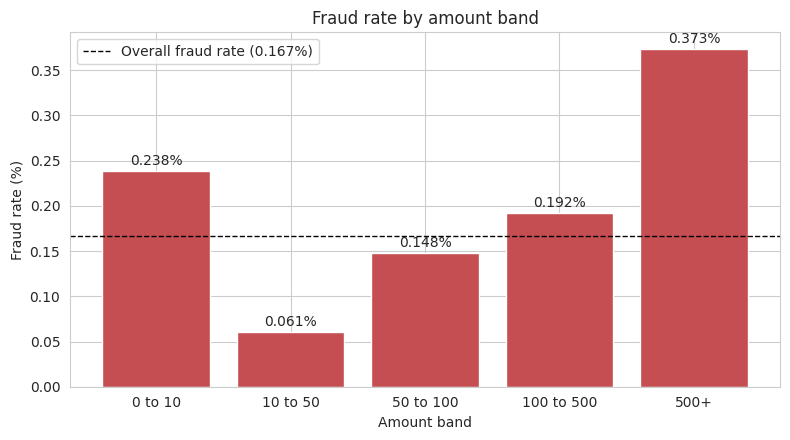

In [16]:
overall_rate = fraud_txn / total_txn * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(band_summary['Amount_Band'].astype(str), band_summary['Fraud_Rate'] * 100, color=COLORS['Fraud'])
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall fraud rate ({overall_rate:.3f}%)')
ax.bar_label(bars, fmt='%.3f%%', padding=2)
ax.set_title('Fraud rate by amount band')
ax.set_xlabel('Amount band')
ax.set_ylabel('Fraud rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

**How to read:** a bar above the dashed line means that band is riskier than average. Notice the pattern is **not a straight line** – risk does not simply rise with amount.

🎤 **Interview tip:** "Amount bands let the business set different review rules for different transaction sizes."

### D. Fraud by time period
**What we are doing:** same calculation by elapsed-time period.

⚠️ **These are elapsed-time bins (hours since the first transaction), not real-world clock time.** We cannot say "night" or "morning".
The dataset covers about 2 days, so period 0–6 hrs and 24–30 hrs are 24 hours apart.

,Time_Period,Total_Transactions,Fraud_Transactions,Fraud_Value,Fraud_Rate_%
0,0 to 6 hrs,12296,55,"5,084.6900",0.4473
1,6 to 12 hrs,34897,91,"9,627.6700",0.2608
2,12 to 18 hrs,46731,71,"9,110.8300",0.1519
3,18 to 24 hrs,50312,55,"8,645.7500",0.1093
4,24 to 30 hrs,11546,60,"4,966.6400",0.5197
5,30 to 36 hrs,35746,27,"4,744.1700",0.0755
6,36 to 42 hrs,49390,62,"10,242.7600",0.1255
7,42 to 48 hrs,42808,52,"6,168.8800",0.1215


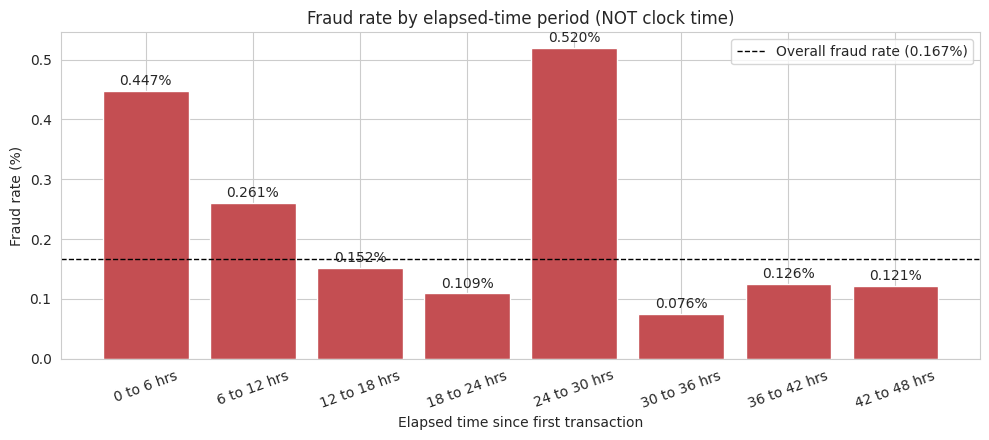

In [17]:
period_summary = df_clean.groupby(['Time_Period', 'Time_Period_Order'], observed=True).agg(
    Total_Transactions=('Class', 'size'),
    Fraud_Transactions=('Class', 'sum'),
    Total_Value=('Amount', 'sum'),
    Fraud_Value=('Fraud_Amount', 'sum')
).reset_index().sort_values('Time_Period_Order')

period_summary['Fraud_Rate'] = period_summary['Fraud_Transactions'] / period_summary['Total_Transactions']

show = period_summary[['Time_Period', 'Total_Transactions', 'Fraud_Transactions', 'Fraud_Value']].copy()
show['Fraud_Rate_%'] = period_summary['Fraud_Rate'] * 100
display(show)

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(period_summary['Time_Period'].astype(str), period_summary['Fraud_Rate'] * 100, color=COLORS['Fraud'])
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1, label=f'Overall fraud rate ({overall_rate:.3f}%)')
ax.bar_label(bars, fmt='%.3f%%', padding=2)
ax.set_title('Fraud rate by elapsed-time period (NOT clock time)')
ax.set_xlabel('Elapsed time since first transaction')
ax.set_ylabel('Fraud rate (%)')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

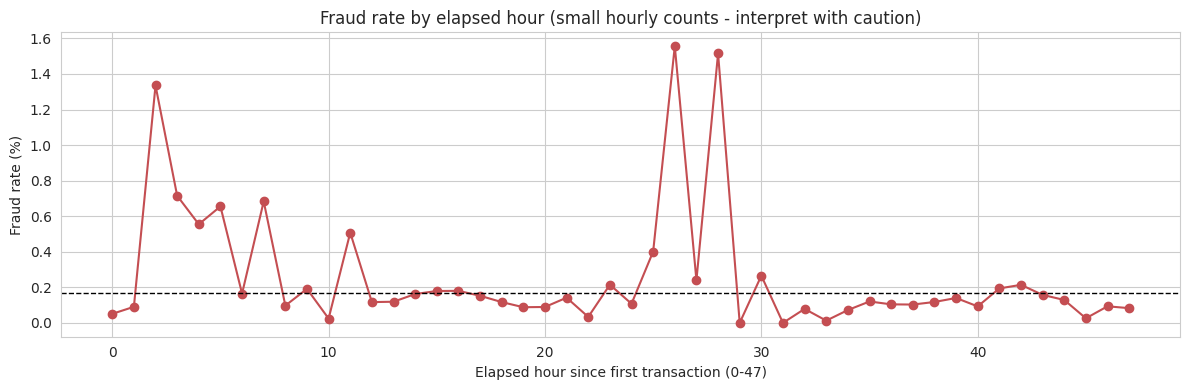

,Elapsed_Hour,Total_Transactions,Fraud_Transactions,Fraud_Value,Fraud_Rate
26,26,1735,27,"1,923.3800",0.0156
28,28,1122,17,757.9400,0.0152
2,2,1573,21,"1,829.7800",0.0134
3,3,1818,13,220.0500,0.0072
7,7,3366,23,"2,757.7800",0.0068


In [18]:
# More detail: fraud rate for every elapsed hour (0-47)
hourly = df_clean.groupby('Elapsed_Hour').agg(
    Total_Transactions=('Class', 'size'),
    Fraud_Transactions=('Class', 'sum'),
    Fraud_Value=('Fraud_Amount', 'sum')
).reset_index()
hourly['Fraud_Rate'] = hourly['Fraud_Transactions'] / hourly['Total_Transactions']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly['Elapsed_Hour'], hourly['Fraud_Rate'] * 100, marker='o', color=COLORS['Fraud'])
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1)
ax.set_title('Fraud rate by elapsed hour (small hourly counts - interpret with caution)')
ax.set_xlabel('Elapsed hour since first transaction (0-47)')
ax.set_ylabel('Fraud rate (%)')
plt.tight_layout()
plt.show()

display(hourly.sort_values('Fraud_Rate', ascending=False).head(5))

**How to read:** hourly fraud counts are small, so single spikes can be random. Look for hours/periods that are high **and** repeat across the two ~24-hour cycles.

🎤 **Interview tip:** "I made time bins to see whether risk changes over the data window, but I was careful to call it elapsed time. With real timestamps I would analyse hour-of-day and day-of-week."

### E. Fraud concentration — frequency vs financial impact
**What we are doing:** for each amount band, what share of **all fraud cases** (frequency) and what share of **all fraud value** (financial impact) it holds.
A band can have many fraud cases but little money, or few cases but a lot of money.

,Amount_Band,Fraud_Transactions,Fraud_Value,% of Fraud Transactions,% of Fraud Value
0,0 to 10,238,449.3100,50.3171,0.7669
1,10 to 50,55,"1,539.8200",11.6279,2.6281
2,50 to 100,55,"4,867.3300",11.6279,8.3072
3,100 to 500,91,"21,052.2800",19.2389,35.9307
4,500+,34,"30,682.6500",7.1882,52.3672


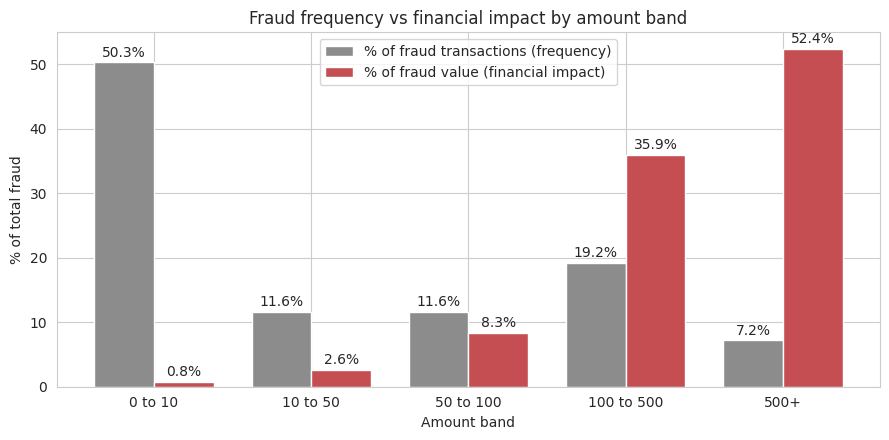

In [19]:
conc = band_summary[['Amount_Band', 'Fraud_Transactions', 'Fraud_Value']].copy()
conc['% of Fraud Transactions'] = band_summary['Fraud_Count_Share'] * 100
conc['% of Fraud Value']        = band_summary['Fraud_Value_Share'] * 100
display(conc)

x = np.arange(len(conc))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w/2, conc['% of Fraud Transactions'], w, label='% of fraud transactions (frequency)', color='#8C8C8C')
b2 = ax.bar(x + w/2, conc['% of Fraud Value'], w, label='% of fraud value (financial impact)', color=COLORS['Fraud'])
ax.bar_label(b1, fmt='%.1f%%', padding=2)
ax.bar_label(b2, fmt='%.1f%%', padding=2)
ax.set_xticks(x)
ax.set_xticklabels(conc['Amount_Band'].astype(str))
ax.set_title('Fraud frequency vs financial impact by amount band')
ax.set_xlabel('Amount band')
ax.set_ylabel('% of total fraud')
ax.legend()
plt.tight_layout()
plt.show()

🎤 **Interview tip:** "Counting fraud cases and measuring fraud money tell different stories. Frequency tells operations where alerts are; value tells risk where losses are."

### F. High-value fraudulent transactions
**What we are doing:** listing the largest fraud transactions and checking how much of the fraud value they hold.
We show only `Time`, `Amount` and engineered columns. We do **not** interpret V1–V28 individually.

,Time,Time_Hours,Time_Period,Amount,Amount_Band,Class
175384,"122,608.0000",34.0578,30 to 36 hrs,"2,125.8700",500+,1
6932,"9,064.0000",2.5178,0 to 6 hrs,"1,809.6800",500+,1
248250,"154,278.0000",42.8550,42 to 48 hrs,"1,504.9300",500+,1
88869,"62,467.0000",17.3519,12 to 18 hrs,"1,402.1600",500+,1
81304,"59,011.0000",16.3919,12 to 18 hrs,"1,389.5600",500+,1
95238,"65,385.0000",18.1625,18 to 24 hrs,"1,354.2500",500+,1
199180,"133,184.0000",36.9956,36 to 42 hrs,"1,335.0000",500+,1
10648,"18,088.0000",5.0244,0 to 6 hrs,"1,218.8900",500+,1
248322,"154,309.0000",42.8636,42 to 48 hrs,"1,096.9900",500+,1
232390,"147,501.0000",40.9725,36 to 42 hrs,996.2700,500+,1


Top 5 fraud transactions = 8,232.20 = 14.1% of total fraud value
Fraud transactions above 500 : 34
Fraud transactions above 1,000: 9
Fraud amount 95th percentile : 655.82
Legitimate amount 99th percentile: 1,018.06


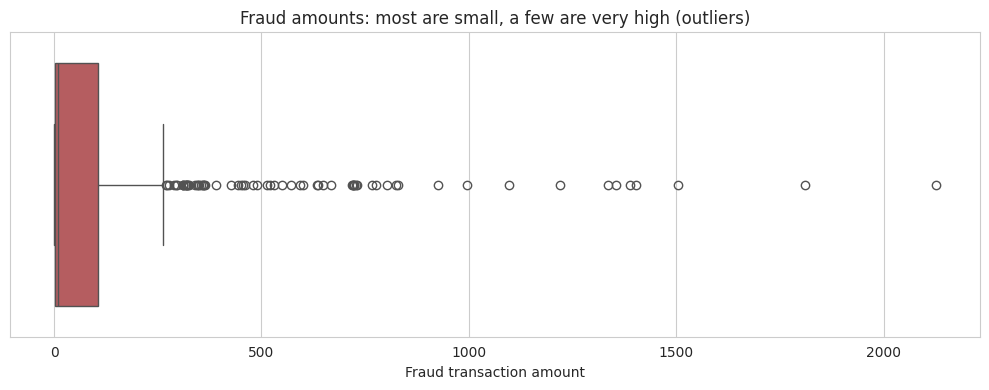

In [20]:
fraud_only = df_clean[df_clean['Class'] == 1].copy()

top_fraud = fraud_only.sort_values('Amount', ascending=False).head(10)
display(top_fraud[['Time', 'Time_Hours', 'Time_Period', 'Amount', 'Amount_Band', 'Class']])

fraud_value = fraud_only['Amount'].sum()
print(f'Top 5 fraud transactions = {top_fraud.head(5)["Amount"].sum():,.2f} '
      f'= {top_fraud.head(5)["Amount"].sum() / fraud_value * 100:.1f}% of total fraud value')
print(f'Fraud transactions above 500 : {(fraud_only["Amount"] > 500).sum()}')
print(f'Fraud transactions above 1,000: {(fraud_only["Amount"] > 1000).sum()}')
print(f'Fraud amount 95th percentile : {fraud_only["Amount"].quantile(0.95):,.2f}')
print(f'Legitimate amount 99th percentile: {df_clean.loc[df_clean["Class"]==0, "Amount"].quantile(0.99):,.2f}')

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=fraud_only['Amount'], color=COLORS['Fraud'], ax=ax)
ax.set_title('Fraud amounts: most are small, a few are very high (outliers)')
ax.set_xlabel('Fraud transaction amount')
plt.tight_layout()
plt.show()

### G. Anonymised feature analysis (V1–V28)
> **These are anonymised PCA-transformed variables, so the analysis identifies statistical patterns rather than directly interpretable business attributes.**

**What we are doing**
1. **Correlation with Class** – a number from −1 to +1. Positive = the feature tends to be higher in fraud; negative = lower in fraud. Closer to ±1 = stronger *linear* association. It is **association, not causation**.
2. **Mean difference** – average of the feature for fraud vs legitimate, divided by the feature's overall standard deviation so features are comparable.
3. **Distribution plots** for the strongest features.

In [21]:
features = [f'V{i}' for i in range(1, 29)]

corr_with_class = df_clean[features + ['Class']].corr()['Class'].drop('Class')     # correlation of each V with Class
mean_legit = df_clean[df_clean['Class'] == 0][features].mean()
mean_fraud = df_clean[df_clean['Class'] == 1][features].mean()
std_all    = df_clean[features].std()

feature_summary = pd.DataFrame({
    'Corr_With_Class': corr_with_class,
    'Abs_Corr': corr_with_class.abs(),
    'Mean_Legitimate': mean_legit,
    'Mean_Fraud': mean_fraud,
    'Mean_Difference': mean_fraud - mean_legit,
    'Std_Mean_Difference': (mean_fraud - mean_legit) / std_all        # difference in "standard deviation units"
})
feature_summary = feature_summary.sort_values('Abs_Corr', ascending=False)
feature_summary['Rank'] = range(1, len(feature_summary) + 1)
feature_summary['Direction'] = np.where(feature_summary['Corr_With_Class'] > 0, 'Higher in fraud', 'Lower in fraud')
feature_summary = feature_summary.reset_index().rename(columns={'index': 'Feature'})

display(feature_summary.head(10))

,Feature,Corr_With_Class,Abs_Corr,Mean_Legitimate,Mean_Fraud,Mean_Difference,Std_Mean_Difference,Rank,Direction
0,V17,-0.3135,0.3135,0.0110,-6.4633,-6.4742,-7.6845,1,Lower in fraud
1,V14,-0.2934,0.2934,0.0117,-6.8359,-6.8476,-7.1912,2,Lower in fraud
2,V12,-0.2507,0.2507,0.0095,-6.1033,-6.1127,-6.1455,3,Lower in fraud
3,V10,-0.2070,0.2070,0.0077,-5.4533,-5.4609,-5.0733,4,Lower in fraud
4,V16,-0.1872,0.1872,0.0078,-4.0010,-4.0088,-4.5883,5,Lower in fraud
5,V3,-0.1823,0.1823,0.0129,-6.7296,-6.7425,-4.4691,6,Lower in fraud
6,V7,-0.1723,0.1723,0.0104,-5.1759,-5.1864,-4.2246,7,Lower in fraud
7,V11,0.1491,0.1491,-0.0060,3.7163,3.7224,3.6539,8,Higher in fraud
8,V4,0.1293,0.1293,-0.0104,4.4726,4.4830,3.1700,9,Higher in fraud
9,V18,-0.1053,0.1053,0.0051,-2.1571,-2.1622,-2.5821,10,Lower in fraud


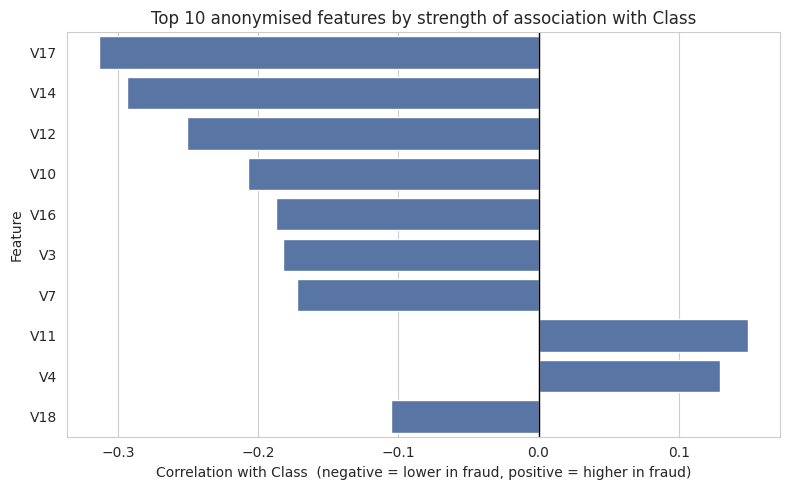

In [22]:
top10 = feature_summary.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y='Feature', x='Corr_With_Class', color='#4C72B0', ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 10 anonymised features by strength of association with Class')
ax.set_xlabel('Correlation with Class  (negative = lower in fraud, positive = higher in fraud)')
plt.tight_layout()
plt.show()

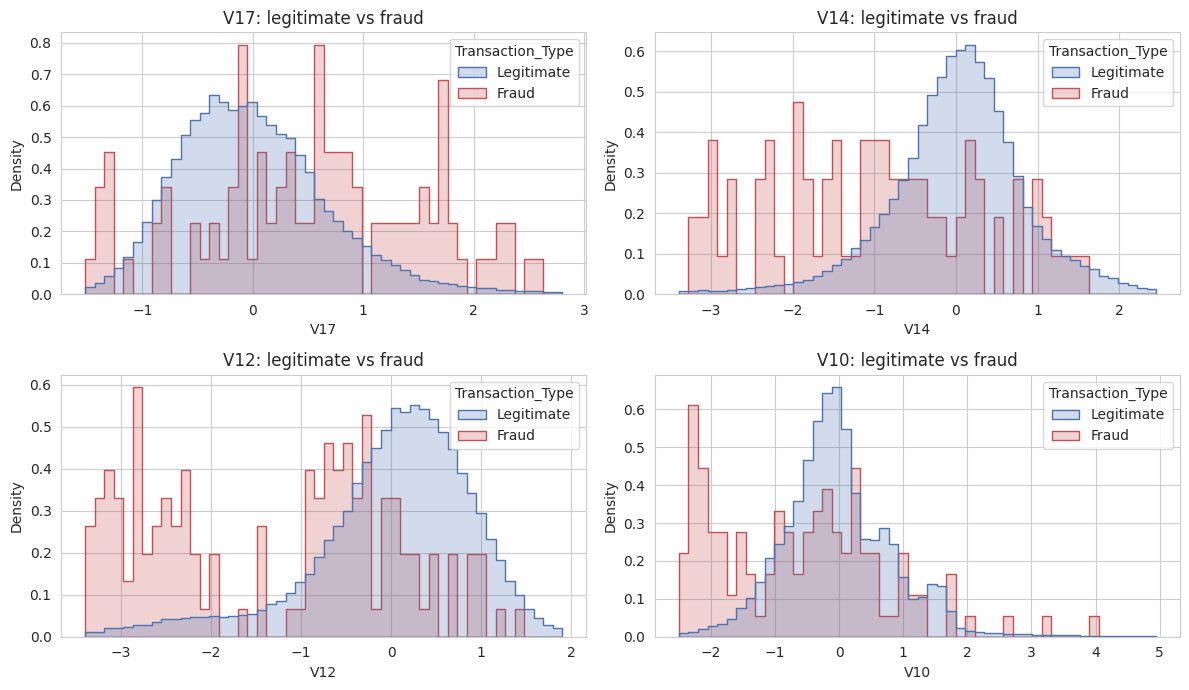

In [23]:
top4 = feature_summary['Feature'].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, f in zip(axes.flatten(), top4):
    low, high = df_clean[f].quantile(0.005), df_clean[f].quantile(0.995)       # trim extreme tails so shapes are visible
    sns.histplot(data=df_clean, x=f, hue='Transaction_Type', hue_order=['Legitimate', 'Fraud'],
                 stat='density', common_norm=False, bins=50, binrange=(low, high),
                 element='step', palette=COLORS, ax=ax)
    ax.set_title(f'{f}: legitimate vs fraud')
plt.tight_layout()
plt.show()

**How to read:** where the red (fraud) curve sits clearly away from the blue (legitimate) curve, the feature separates the two groups. We do **not** say what the feature means in business terms.

🎤 **Interview tip:** "V1–V28 are PCA components so I treated them only as statistical signals. I ranked them by correlation with Class and compared distributions. I did not give them business names."

## SECTION 6 — Fraud KPIs
**What we are doing:** building the 10 KPIs a fraud-monitoring dashboard needs, each with a clear formula.

**Key difference to remember**
- **Fraud Rate %** = *how often* fraud happens (count based).
- **Fraud Value Rate %** = *how much money* is fraud (value based).

In [24]:
total_value        = df_clean['Amount'].sum()
fraud_value        = df_clean.loc[df_clean['Class'] == 1, 'Amount'].sum()
fraud_value_rate   = fraud_value / total_value * 100
avg_amount         = df_clean['Amount'].mean()
avg_fraud          = df_clean.loc[df_clean['Class'] == 1, 'Amount'].mean()
avg_legit          = df_clean.loc[df_clean['Class'] == 0, 'Amount'].mean()
median_fraud       = df_clean.loc[df_clean['Class'] == 1, 'Amount'].median()
median_legit       = df_clean.loc[df_clean['Class'] == 0, 'Amount'].median()
max_fraud          = df_clean.loc[df_clean['Class'] == 1, 'Amount'].max()

kpi = pd.DataFrame({
    'KPI': ['Total Transactions', 'Fraud Transactions', 'Legitimate Transactions', 'Fraud Rate %',
            'Total Transaction Value', 'Fraud Transaction Value', 'Fraud Value Rate %',
            'Average Transaction Amount', 'Average Fraud Amount', 'Maximum Fraud Amount'],
    'Value': [total_txn, fraud_txn, legit_txn, fraud_rate_pct,
              total_value, fraud_value, fraud_value_rate,
              avg_amount, avg_fraud, max_fraud],
    'Formula': ['COUNT of all transactions',
                'COUNT of transactions where Class = 1',
                'COUNT of transactions where Class = 0',
                'Fraud Transactions / Total Transactions x 100',
                'SUM of Amount (all transactions)',
                'SUM of Amount where Class = 1',
                'Fraud Transaction Value / Total Transaction Value x 100',
                'Total Transaction Value / Total Transactions',
                'Fraud Transaction Value / Fraud Transactions',
                'MAX of Amount where Class = 1'],
    'Business_Question': ['How big is the portfolio?', 'How many frauds?', 'How many genuine customers transacted?',
                          'How often does fraud occur?', 'How much money flows?', 'How much money is fraud?',
                          'What share of money is fraud?', 'What is a typical transaction size?',
                          'What is a typical fraud size?', 'What is the worst single fraud loss?']
})

kpi_display = kpi.copy()
kpi_display['Value'] = [f'{v:,.0f}' if i < 3 else f'{v:,.4f}' if i in (3, 6) else f'{v:,.2f}' for i, v in enumerate(kpi['Value'])]
display(kpi_display)

,KPI,Value,Formula,Business_Question
0,Total Transactions,"283,726",COUNT of all transactions,How big is the portfolio?
1,Fraud Transactions,473,COUNT of transactions where Class = 1,How many frauds?
2,Legitimate Transactions,"283,253",COUNT of transactions where Class = 0,How many genuine customers transacted?
3,Fraud Rate %,0.1667,Fraud Transactions / Total Transactions x 100,How often does fraud occur?
4,Total Transaction Value,"25,102,001.68",SUM of Amount (all transactions),How much money flows?
5,Fraud Transaction Value,"58,591.39",SUM of Amount where Class = 1,How much money is fraud?
6,Fraud Value Rate %,0.2334,Fraud Transaction Value / Total Transaction Va...,What share of money is fraud?
7,Average Transaction Amount,88.47,Total Transaction Value / Total Transactions,What is a typical transaction size?
8,Average Fraud Amount,123.87,Fraud Transaction Value / Fraud Transactions,What is a typical fraud size?
9,Maximum Fraud Amount,"2,125.87",MAX of Amount where Class = 1,What is the worst single fraud loss?


🎤 **Interview tip:** "The most useful KPI for a fraud team is *fraud rate* for monitoring trends and *fraud value* for prioritising losses. Both together show frequency and impact."

## SECTION 7 — Business insights
Every number below is **calculated from your data by code** (nothing is typed in by hand), so the insights always match the results.

In [25]:
hi_band = band_summary.loc[band_summary['Fraud_Rate'].idxmax()]
lo_band = band_summary.loc[band_summary['Fraud_Rate'].idxmin()]
small_band = band_summary.iloc[0]          # '0 to 10'
big_band   = band_summary.iloc[-1]         # '500+'
hi_per = period_summary.loc[period_summary['Fraud_Rate'].idxmax()]
lo_per = period_summary.loc[period_summary['Fraud_Rate'].idxmin()]
top_hours = hourly.sort_values('Fraud_Rate', ascending=False).head(3)
top3_feat = feature_summary.head(3)
top5_share = top_fraud.head(5)['Amount'].sum() / fraud_value * 100
n_fraud_500 = int((fraud_only['Amount'] > 500).sum())
baseline_accuracy = legit_txn / total_txn * 100
bands_100_plus_value = band_summary[band_summary['Amount_Band'].isin(['100 to 500', '500+'])]['Fraud_Value_Share'].sum() * 100
bands_100_plus_count = band_summary[band_summary['Amount_Band'].isin(['100 to 500', '500+'])]['Fraud_Count_Share'].sum() * 100

insights = f'''
### Insight 1 — Fraud is rare but real
**Finding:** Fraud is a very small share of all transactions.

**Evidence:** {fraud_txn:,} of {total_txn:,} transactions are fraud = **{fraud_rate_pct:.4f}%** (about 1 in {round(100/fraud_rate_pct):,}).

**Business meaning:** Fraud is easy to miss in totals. The team needs a dedicated fraud-rate KPI and cannot rely on overall volume reports.

### Insight 2 — Class imbalance makes "accuracy" a useless KPI
**Finding:** A rule that labels every transaction "legitimate" would look almost perfect.

**Evidence:** That rule would be right {baseline_accuracy:.2f}% of the time but would catch 0 of {fraud_txn:,} frauds.

**Business meaning:** Fraud monitoring must use fraud rate, fraud value and detection-focused measures, never overall accuracy.

### Insight 3 — Fraud money share is {'higher' if fraud_value_rate > fraud_rate_pct else 'lower'} than fraud count share
**Finding:** Fraud value rate and fraud rate measure different things.

**Evidence:** Fraud rate = {fraud_rate_pct:.4f}% of transactions, fraud value rate = {fraud_value_rate:.4f}% of money. Total fraud value = {fraud_value:,.2f} out of {total_value:,.2f}.

**Business meaning:** Report both: frequency drives alert workload, value drives financial loss.

### Insight 4 — Typical fraud is small, but average fraud is pulled up by large cases
**Finding:** The median fraud amount is lower than the median legitimate amount, but the average fraud amount is higher than the average legitimate amount.

**Evidence:** Median fraud = {median_fraud:,.2f} vs median legitimate = {median_legit:,.2f}. Average fraud = {avg_fraud:,.2f} vs average legitimate = {avg_legit:,.2f}.

**Business meaning:** Most frauds are small-value, while a minority of large frauds raise the average. Rules that only target large amounts would miss most fraud cases.

### Insight 5 — Small transactions hold half the fraud cases but little of the money
**Finding:** The '0 to 10' band has the largest share of fraud cases but a tiny share of fraud value.

**Evidence:** '0 to 10' holds {small_band['Fraud_Count_Share']*100:.1f}% of fraud transactions but only {small_band['Fraud_Value_Share']*100:.2f}% of fraud value.

**Business meaning:** These are a high-volume, low-loss problem – best handled by automated rules/step-up checks rather than manual review of each case.

### Insight 6 — Fraud rate and fraud money both vary sharply by amount band
**Finding:** The '{hi_band['Amount_Band']}' band has the highest fraud rate; the lowest is '{lo_band['Amount_Band']}'. Risk does not rise steadily with amount.

**Evidence:** Highest = {hi_band['Fraud_Rate']*100:.3f}% ({hi_band['Fraud_Rate']*100/fraud_rate_pct:.1f}x the overall rate); lowest = {lo_band['Fraud_Rate']*100:.3f}%. The '500+' band is {big_band['Total_Transactions']/total_txn*100:.1f}% of transactions but {big_band['Fraud_Value_Share']*100:.1f}% of fraud value. Bands above 100 together hold {bands_100_plus_value:.1f}% of fraud value from {bands_100_plus_count:.1f}% of fraud cases.

**Business meaning:** Financial loss is concentrated in a small number of high-value transactions, so high-value transactions deserve closer review.

### Insight 7 — Fraud rate differs between elapsed-time periods
**Finding:** Fraud rate is not constant across the data window.

**Evidence:** Highest in '{hi_per['Time_Period']}' ({hi_per['Fraud_Rate']*100:.3f}%); lowest in '{lo_per['Time_Period']}' ({lo_per['Fraud_Rate']*100:.3f}%). Overall = {fraud_rate_pct:.3f}%. Highest elapsed hours: {', '.join(str(int(h)) for h in top_hours['Elapsed_Hour'])} (rates {', '.join(f'{r*100:.2f}%' for r in top_hours['Fraud_Rate'])}). The highest-rate period had {int(hi_per['Total_Transactions']):,} transactions and {int(hi_per['Fraud_Transactions'])} frauds, versus an average of {period_summary['Total_Transactions'].mean():,.0f} transactions and {period_summary['Fraud_Transactions'].mean():.0f} frauds per period.

**Business meaning:** Risk monitoring should track fraud rate over time. A quieter period can show a high fraud rate because fraud counts do not fall as much as genuine traffic (a pattern to verify with real data), so always read rate together with volume. These are **elapsed** periods, not clock time, so real timestamps are needed before choosing staffing or time-based rules.

### Insight 8 — A small group of high-value frauds carries a large share of the loss
**Finding:** Fraud transactions above 500 are few but hold a large share of fraud money.

**Evidence:** Largest fraud = {max_fraud:,.2f}. {n_fraud_500} fraud transactions exceed 500 ({n_fraud_500/fraud_txn*100:.1f}% of fraud cases) and the '500+' band holds {big_band['Fraud_Value_Share']*100:.1f}% of fraud value. The top 5 alone = {top5_share:.1f}% of fraud value.

**Business meaning:** A small high-value review queue can cover a large part of the money at risk.

### Insight 9 — A few anonymised features are statistically linked to fraud
**Finding:** Some PCA features separate fraud from legitimate better than others.

**Evidence:** Strongest by absolute correlation with Class: {top3_feat.iloc[0]['Feature']} ({top3_feat.iloc[0]['Corr_With_Class']:.3f}), {top3_feat.iloc[1]['Feature']} ({top3_feat.iloc[1]['Corr_With_Class']:.3f}), {top3_feat.iloc[2]['Feature']} ({top3_feat.iloc[2]['Corr_With_Class']:.3f}).

**Business meaning:** These are statistical signals only (anonymised PCA variables). They suggest the bank's own data science team could use the underlying real attributes for pattern/anomaly rules, but they cannot be explained in business terms here.

### Insight 10 — Zero-amount and duplicate records need data governance
**Finding:** The raw file contained duplicate records and zero-amount transactions.

**Evidence:** {duplicate_rows:,} exact duplicate rows ({duplicate_fraud} fraud) and {zero_amount:,} zero-amount rows ({zero_amount_fraud} fraud) in the raw file.

**Business meaning:** Reporting KPIs from raw data would slightly overstate counts. A fraud dashboard needs de-duplication rules and a clear policy for zero-amount records.
'''
display(Markdown(insights))


### Insight 1 — Fraud is rare but real
**Finding:** Fraud is a very small share of all transactions.

**Evidence:** 473 of 283,726 transactions are fraud = **0.1667%** (about 1 in 600).

**Business meaning:** Fraud is easy to miss in totals. The team needs a dedicated fraud-rate KPI and cannot rely on overall volume reports.

### Insight 2 — Class imbalance makes "accuracy" a useless KPI
**Finding:** A rule that labels every transaction "legitimate" would look almost perfect.

**Evidence:** That rule would be right 99.83% of the time but would catch 0 of 473 frauds.

**Business meaning:** Fraud monitoring must use fraud rate, fraud value and detection-focused measures, never overall accuracy.

### Insight 3 — Fraud money share is higher than fraud count share
**Finding:** Fraud value rate and fraud rate measure different things.

**Evidence:** Fraud rate = 0.1667% of transactions, fraud value rate = 0.2334% of money. Total fraud value = 58,591.39 out of 25,102,001.68.

**Business meaning:** Report both: frequency drives alert workload, value drives financial loss.

### Insight 4 — Typical fraud is small, but average fraud is pulled up by large cases
**Finding:** The median fraud amount is lower than the median legitimate amount, but the average fraud amount is higher than the average legitimate amount.

**Evidence:** Median fraud = 9.82 vs median legitimate = 22.00. Average fraud = 123.87 vs average legitimate = 88.41.

**Business meaning:** Most frauds are small-value, while a minority of large frauds raise the average. Rules that only target large amounts would miss most fraud cases.

### Insight 5 — Small transactions hold half the fraud cases but little of the money
**Finding:** The '0 to 10' band has the largest share of fraud cases but a tiny share of fraud value.

**Evidence:** '0 to 10' holds 50.3% of fraud transactions but only 0.77% of fraud value.

**Business meaning:** These are a high-volume, low-loss problem – best handled by automated rules/step-up checks rather than manual review of each case.

### Insight 6 — Fraud rate and fraud money both vary sharply by amount band
**Finding:** The '500+' band has the highest fraud rate; the lowest is '10 to 50'. Risk does not rise steadily with amount.

**Evidence:** Highest = 0.373% (2.2x the overall rate); lowest = 0.061%. The '500+' band is 3.2% of transactions but 52.4% of fraud value. Bands above 100 together hold 88.3% of fraud value from 26.4% of fraud cases.

**Business meaning:** Financial loss is concentrated in a small number of high-value transactions, so high-value transactions deserve closer review.

### Insight 7 — Fraud rate differs between elapsed-time periods
**Finding:** Fraud rate is not constant across the data window.

**Evidence:** Highest in '24 to 30 hrs' (0.520%); lowest in '30 to 36 hrs' (0.076%). Overall = 0.167%. Highest elapsed hours: 26, 28, 2 (rates 1.56%, 1.52%, 1.34%). The highest-rate period had 11,546 transactions and 60 frauds, versus an average of 35,466 transactions and 59 frauds per period.

**Business meaning:** Risk monitoring should track fraud rate over time. A quieter period can show a high fraud rate because fraud counts do not fall as much as genuine traffic (a pattern to verify with real data), so always read rate together with volume. These are **elapsed** periods, not clock time, so real timestamps are needed before choosing staffing or time-based rules.

### Insight 8 — A small group of high-value frauds carries a large share of the loss
**Finding:** Fraud transactions above 500 are few but hold a large share of fraud money.

**Evidence:** Largest fraud = 2,125.87. 34 fraud transactions exceed 500 (7.2% of fraud cases) and the '500+' band holds 52.4% of fraud value. The top 5 alone = 14.1% of fraud value.

**Business meaning:** A small high-value review queue can cover a large part of the money at risk.

### Insight 9 — A few anonymised features are statistically linked to fraud
**Finding:** Some PCA features separate fraud from legitimate better than others.

**Evidence:** Strongest by absolute correlation with Class: V17 (-0.313), V14 (-0.293), V12 (-0.251).

**Business meaning:** These are statistical signals only (anonymised PCA variables). They suggest the bank's own data science team could use the underlying real attributes for pattern/anomaly rules, but they cannot be explained in business terms here.

### Insight 10 — Zero-amount and duplicate records need data governance
**Finding:** The raw file contained duplicate records and zero-amount transactions.

**Evidence:** 1,081 exact duplicate rows (19 fraud) and 1,825 zero-amount rows (27 fraud) in the raw file.

**Business meaning:** Reporting KPIs from raw data would slightly overstate counts. A fraud dashboard needs de-duplication rules and a clear policy for zero-amount records.


## SECTION 8 — Business recommendations
These are **recommendations suggested by the observed patterns**. They are *not guaranteed* to reduce fraud; each should be tested (e.g. on a pilot or with historical back-testing) before full rollout. Numbers are calculated from your data.

In [26]:
recs = f'''
### Recommendation 1 — Prioritise a high-value review queue
**Linked finding:** '500+' band has the highest fraud rate ({big_band['Fraud_Rate']*100:.3f}%) and {big_band['Fraud_Value_Share']*100:.1f}% of fraud value.
**Action:** Create a priority alert queue for the highest-value transactions so analysts see them first.
**Stakeholder:** Fraud Operations Manager. **Measure of success:** share of fraud value caught in this queue; review time.

### Recommendation 2 — Use risk-based authentication for transactions above 100
**Linked finding:** Bands above 100 hold {bands_100_plus_value:.1f}% of fraud value from {bands_100_plus_count:.1f}% of fraud cases.
**Action:** Trigger extra verification (e.g. one-time code) instead of blocking, to protect money while limiting customer friction.
**Stakeholder:** Head of Risk / Card Product Manager. **Measure:** fraud value rate, customer drop-off at verification.

### Recommendation 3 — Handle small-value fraud with automated rules, not manual review
**Linked finding:** '0 to 10' band has {small_band['Fraud_Count_Share']*100:.1f}% of fraud cases but {small_band['Fraud_Value_Share']*100:.2f}% of fraud value.
**Action:** Add automated checks such as transaction velocity monitoring (many small transactions in a short time). This is a hypothesis to test with the bank's real data.
**Stakeholder:** Fraud Operations / Analytics. **Measure:** fraud count in small bands; alert volume.

### Recommendation 4 — Monitor fraud rate across time windows
**Linked finding:** fraud rate ranges from {lo_per['Fraud_Rate']*100:.3f}% to {hi_per['Fraud_Rate']*100:.3f}% across elapsed-time periods.
**Action:** Track fraud rate by time window on the dashboard and set alert thresholds. With real timestamps, analyse hour-of-day / day-of-week before changing staffing.
**Stakeholder:** Fraud Operations Manager. **Measure:** fraud rate per window vs threshold.

### Recommendation 5 — Add anomaly-pattern alerts using the strongest statistical features
**Linked finding:** {top3_feat.iloc[0]['Feature']}, {top3_feat.iloc[1]['Feature']} and {top3_feat.iloc[2]['Feature']} show the strongest association with fraud.
**Action:** Ask the data-science team to test simple anomaly rules on the real (non-anonymised) attributes behind such patterns, and use them to rank alerts.
**Stakeholder:** Risk Analytics team. **Measure:** share of alerts that turn out to be fraud (alert precision).

### Recommendation 6 — Run a continuous fraud KPI dashboard
**Linked finding:** Fraud is rare ({fraud_rate_pct:.4f}%) and accuracy is misleading.
**Action:** Monitor Fraud Rate %, Fraud Value Rate %, Average/Max Fraud Amount and fraud concentration by amount band every day/week, with thresholds that trigger investigation.
**Stakeholder:** Head of Risk, Senior Management. **Measure:** dashboard refreshed on schedule; time to detect a rate spike.

### Recommendation 7 — Improve data capture
**Linked finding:** No merchant, country, channel or real timestamp in this dataset; duplicates exist.
**Action:** Capture merchant category, location, channel, real timestamps and a unique transaction ID so deeper analysis is possible and duplicates are avoidable.
**Stakeholder:** Data Engineering / Risk. **Measure:** data completeness; duplicate rate.
'''
display(Markdown(recs))


### Recommendation 1 — Prioritise a high-value review queue
**Linked finding:** '500+' band has the highest fraud rate (0.373%) and 52.4% of fraud value.
**Action:** Create a priority alert queue for the highest-value transactions so analysts see them first.
**Stakeholder:** Fraud Operations Manager. **Measure of success:** share of fraud value caught in this queue; review time.

### Recommendation 2 — Use risk-based authentication for transactions above 100
**Linked finding:** Bands above 100 hold 88.3% of fraud value from 26.4% of fraud cases.
**Action:** Trigger extra verification (e.g. one-time code) instead of blocking, to protect money while limiting customer friction.
**Stakeholder:** Head of Risk / Card Product Manager. **Measure:** fraud value rate, customer drop-off at verification.

### Recommendation 3 — Handle small-value fraud with automated rules, not manual review
**Linked finding:** '0 to 10' band has 50.3% of fraud cases but 0.77% of fraud value.
**Action:** Add automated checks such as transaction velocity monitoring (many small transactions in a short time). This is a hypothesis to test with the bank's real data.
**Stakeholder:** Fraud Operations / Analytics. **Measure:** fraud count in small bands; alert volume.

### Recommendation 4 — Monitor fraud rate across time windows
**Linked finding:** fraud rate ranges from 0.076% to 0.520% across elapsed-time periods.
**Action:** Track fraud rate by time window on the dashboard and set alert thresholds. With real timestamps, analyse hour-of-day / day-of-week before changing staffing.
**Stakeholder:** Fraud Operations Manager. **Measure:** fraud rate per window vs threshold.

### Recommendation 5 — Add anomaly-pattern alerts using the strongest statistical features
**Linked finding:** V17, V14 and V12 show the strongest association with fraud.
**Action:** Ask the data-science team to test simple anomaly rules on the real (non-anonymised) attributes behind such patterns, and use them to rank alerts.
**Stakeholder:** Risk Analytics team. **Measure:** share of alerts that turn out to be fraud (alert precision).

### Recommendation 6 — Run a continuous fraud KPI dashboard
**Linked finding:** Fraud is rare (0.1667%) and accuracy is misleading.
**Action:** Monitor Fraud Rate %, Fraud Value Rate %, Average/Max Fraud Amount and fraud concentration by amount band every day/week, with thresholds that trigger investigation.
**Stakeholder:** Head of Risk, Senior Management. **Measure:** dashboard refreshed on schedule; time to detect a rate spike.

### Recommendation 7 — Improve data capture
**Linked finding:** No merchant, country, channel or real timestamp in this dataset; duplicates exist.
**Action:** Capture merchant category, location, channel, real timestamps and a unique transaction ID so deeper analysis is possible and duplicates are avoidable.
**Stakeholder:** Data Engineering / Risk. **Measure:** data completeness; duplicate rate.


## SECTION 9 — Export files for Power BI (and Excel)
**What we are doing:** saving 8 CSV files into one folder, zipping the folder and downloading **one ZIP** (browsers often block many separate downloads).

| File | Use in Power BI |
|---|---|
| `fraud_cleaned.csv` | **Main table** – all dashboard visuals and DAX measures |
| `fraud_kpi_summary.csv` | Check your Power BI KPI cards match Python |
| `fraud_by_amount_band.csv` | Validation / optional tables |
| `fraud_by_time_period.csv` | Validation / optional tables |
| `fraud_by_elapsed_hour.csv` | Optional hourly trend (also buildable from main table) |
| `fraud_by_transaction_type.csv` | Amount comparison (average, median, percentiles) |
| `fraud_feature_summary.csv` | V1–V28 feature chart |
| `top_fraud_transactions.csv` | Top-fraud table |

Rates are saved as **decimals** (0.0024 = 0.24%) so Power BI/Excel can show them with percentage formatting.

In [27]:
out_dir = 'fraud_project_outputs'
os.makedirs(out_dir, exist_ok=True)

# 1. fraud_cleaned.csv  (transaction-level)
cleaned_cols = ['Time', 'Time_Hours', 'Elapsed_Hour', 'Time_Period', 'Time_Period_Order',
                'Amount', 'Amount_Band', 'Amount_Band_Order', 'Class', 'Transaction_Type'] + features
df_clean[cleaned_cols].to_csv(f'{out_dir}/fraud_cleaned.csv', index=False)

# 2. fraud_kpi_summary.csv
kpi.to_csv(f'{out_dir}/fraud_kpi_summary.csv', index=False)

# 3. fraud_by_amount_band.csv
band_out = band_summary[['Amount_Band', 'Total_Transactions', 'Fraud_Transactions', 'Fraud_Rate', 'Fraud_Value',
                         'Total_Value', 'Fraud_Count_Share', 'Fraud_Value_Share', 'Sort_Order']]
band_out.to_csv(f'{out_dir}/fraud_by_amount_band.csv', index=False)

# 4. fraud_by_time_period.csv
period_out = period_summary[['Time_Period', 'Total_Transactions', 'Fraud_Transactions', 'Fraud_Rate', 'Fraud_Value',
                             'Total_Value', 'Time_Period_Order']].rename(columns={'Time_Period_Order': 'Sort_Order'})
period_out.to_csv(f'{out_dir}/fraud_by_time_period.csv', index=False)

# 5. fraud_by_elapsed_hour.csv
hourly.to_csv(f'{out_dir}/fraud_by_elapsed_hour.csv', index=False)

# 6. fraud_by_transaction_type.csv  (amount statistics for Legitimate vs Fraud)
type_out = amount_stats.join(percentiles[['P25', 'P75', 'P90', 'P95', 'P99']]).reset_index()
type_out = type_out.rename(columns={'Average': 'Average_Amount', 'Median': 'Median_Amount',
                                    'Maximum': 'Maximum_Amount', 'Total': 'Total_Amount'})
type_out.to_csv(f'{out_dir}/fraud_by_transaction_type.csv', index=False)

# 7. fraud_feature_summary.csv
feature_summary.to_csv(f'{out_dir}/fraud_feature_summary.csv', index=False)

# 8. top_fraud_transactions.csv  (top 20 fraud by Amount + 3 strongest statistical features)
top3_names = feature_summary['Feature'].head(3).tolist()
top_fraud_out = fraud_only.sort_values('Amount', ascending=False).head(20)[
    ['Time', 'Time_Hours', 'Time_Period', 'Amount', 'Amount_Band', 'Class'] + top3_names].reset_index(drop=True)
top_fraud_out.insert(0, 'Rank', range(1, len(top_fraud_out) + 1))
top_fraud_out.to_csv(f'{out_dir}/top_fraud_transactions.csv', index=False)

print('Files saved ✅')

Files saved ✅


In [28]:
# Show saved files, size and shape
rows = []
for f in sorted(os.listdir(out_dir)):
    path = f'{out_dir}/{f}'
    t = pd.read_csv(path)
    rows.append([f, t.shape[0], t.shape[1], round(os.path.getsize(path) / 1024 / 1024, 2)])
display(pd.DataFrame(rows, columns=['File', 'Rows', 'Columns', 'Size_MB']))

# Zip and download ONE file
zip_name = 'fraud_project_outputs.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir(out_dir):
        z.write(f'{out_dir}/{f}', arcname=f)

from google.colab import files
files.download(zip_name)
print('Download started: unzip fraud_project_outputs.zip on your computer, then import the CSVs into Power BI.')

,File,Rows,Columns,Size_MB
0,fraud_by_amount_band.csv,5,9,0.0000
1,fraud_by_elapsed_hour.csv,48,5,0.0000
2,fraud_by_time_period.csv,8,7,0.0000
3,fraud_by_transaction_type.csv,2,11,0.0000
4,fraud_cleaned.csv,283726,38,158.6900
5,fraud_feature_summary.csv,28,9,0.0000
6,fraud_kpi_summary.csv,10,4,0.0000
7,top_fraud_transactions.csv,20,10,0.0000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: unzip fraud_project_outputs.zip on your computer, then import the CSVs into Power BI.


### Which files go into Power BI?
- **Always import:** `fraud_cleaned.csv` (main table).
- **Also import:** `fraud_feature_summary.csv` (feature chart), `fraud_by_transaction_type.csv` (amount comparison).
- **Optional / for validation:** `fraud_kpi_summary.csv`, `fraud_by_amount_band.csv`, `fraud_by_time_period.csv`, `fraud_by_elapsed_hour.csv`, `top_fraud_transactions.csv`.

Follow the separate **Power BI Dashboard Guide** for step-by-step instructions.

## ✅ Python project checklist
- [x] Business problem, objectives, stakeholders defined
- [x] Data loaded once; shape, types, descriptive statistics shown
- [x] Data-quality check (missing, duplicates, invalid, zero amount, class imbalance)
- [x] Cleaning decisions documented (exact duplicates removed, zero amounts kept)
- [x] Features created: Transaction_Type, Time_Hours, Time_Period, Elapsed_Hour, Amount_Band
- [x] EDA A–G completed with charts
- [x] 10 KPIs with formulas
- [x] 10 data-driven insights (numbers computed by code)
- [x] 7 stakeholder recommendations linked to findings
- [x] 8 CSV files exported and zipped for Power BI